In [1]:
from spin_sampler import Sampler , define_hopfield_model , initialize_spins
from binary_dimension import compute_histogram_jax, select_range, highest_prob_range , compute_histogram
from binary_dimension.utils import initial_gauss
from binary_dimension.optimization import DKL_Optimizer
from binary_dimension.distance_models import LinearDistanceModel , PolynomialDistanceModel
import numpy as np
import matplotlib.pyplot as plt 
import time

In [2]:
# Parameters of the simulation
N = 1000
N_samples = 1000
dt_samples = 1
N_walkers = 1
T = 1.0
alpha = 0.04
mode = 'single_chain' 
backend = 'numba'  # 'numpy' or 'jax'
rnd_ord = True
seed = int(time.time()) #
seed = 123
store = True

# Define the couplings of Hopfield model and initialize spins
p = int(alpha * N)
J , patterns = define_hopfield_model(N,p,N_walkers,mode,backend,seed)
initial_state = initialize_spins(N,N_walkers,mode,backend,seed)

# Create a sampler instance and sample
sampler = Sampler(J, T, mode,backend)
sampler.run_gibbs(initial_state,N_samples,dt_samples,rnd_ord,seed,store,progress=True);
S = sampler.get_chain()
sampler.reset_chain() # Clean up the sampler
print(f'Chain shape: {S.shape}') # (N_walkers,N_samples,N)
r , P = compute_histogram(S)

  8%|▊         | 78/1000 [00:00<00:01, 777.21it/s]

100%|██████████| 1000/1000 [00:01<00:00, 841.62it/s]


Chain shape: (1000, 1000)


Optimized parameters theta: [450.96158868   0.89169895]
Log D_KL at optimum: -9.385191646640736
Number of iterations: 19


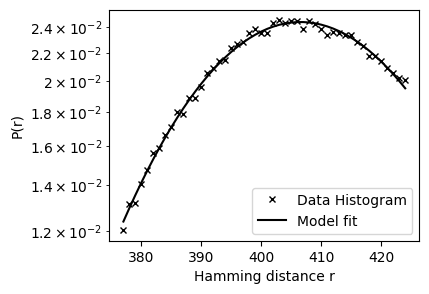

In [9]:
def compute_BID(r,P,a_min=0.01,a_max=0.2,max_iter=1000,error=1e-10,lr=1.2,verbose=True):

  ### Select range for fitting
  _r,_P = select_range(r, P, a_min=a_min, a_max=a_max) 
  
  ### Initialization of parameters and optimizer
  distance_model = LinearDistanceModel()
  theta_init = initial_gauss(_r,_P)
  Dkl_optimizer = DKL_Optimizer(_r,_P, distance_model)

  ### Optimization
  theta_opt , log_DKL , Nit = Dkl_optimizer.optimize(theta_init,max_iter=max_iter,error=error,lr=lr)

  ### Computing P_model with optimizer parameters
  Pmod = distance_model.P_model(_r, theta_opt)

  if verbose: 
    print(f'Optimized parameters theta: {theta_opt}')
    print(f'Log D_KL at optimum: {log_DKL}')
    print(f'Number of iterations: {Nit}') 

  return theta_opt, log_DKL, Nit, _r, _P, Pmod

### Fit parameters 
a_min = 0.1 # min order of quantile of the distance distribution, between 0 and a_max
a_max = .7 # max order of quantile of the distance distribution, between a_min and 1
max_iter = 1000 # maximum number of optimization iterations, default value
error = 1e-10 # convergence error, default value
lr = 1.2 # default value 

(theta_opt, log_DKL, Nit,
 _r, _P, Pmod) = compute_BID(r=r,
                            P=P,
                            a_min=a_min,
                            a_max=a_max,
                            max_iter=max_iter,
                            error=error,
                            lr=lr)

### Plotting
fig,ax = plt.subplots(1,figsize=(4,3))

ax.plot(_r,_P,'x',markersize=5,color='black',label='Data Histogram')
ax.plot(_r,Pmod,color='black', label='Model fit')
ax.legend()

ax.set_xlabel('Hamming distance r')
ax.set_ylabel('P(r)')
ax.set_yscale('log')

plt.show()

Optimized parameters theta: [461.59033154   0.8599064 ]
Log D_KL at optimum: -9.761761642578183
Number of iterations: 34


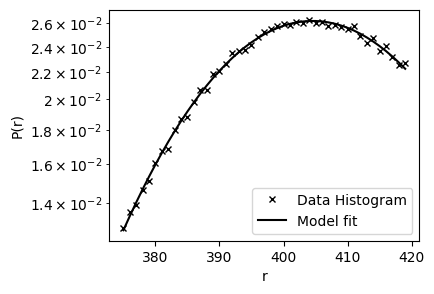

In [ ]:
fig,ax = plt.subplots(1,figsize=(4,3))


### Fit parameters 
a_min = 0.1 # min quantile of the distance distribution, between 0 and a_max
a_max = .7 # max quantile of the distance distribution, between a_min and 1

### Select range for fitting
_r,_P = select_range(r, P, a_min=a_min, a_max=a_max) 

### Initialization of parameters and optimizer
distance_model = LinearDistanceModel()
theta_init = initial_gauss(_r,_P)
Dkl_optimizer = DKL_Optimizer(_r,_P, distance_model)

### Optimization
theta_opt , log_DKL , Nit = Dkl_optimizer.optimize(theta_init,max_iter=1000,error=1e-10,lr=1.2)

### Computing P_model with optimizer parameters
Pmod = distance_model.P_model(_r, theta_opt)

### Plotting
ax.plot(_r,_P,'x',markersize=5,color='black',label='Data Histogram')
ax.plot(_r,Pmod,color='black', label='Model fit')
ax.legend()

ax.set_xlabel('r')
ax.set_ylabel('P(r)')
ax.set_yscale('log')

print(f'Optimized parameters theta: {theta_opt}')
print(f'Log D_KL at optimum: {log_DKL}')
print(f'Number of iterations: {Nit}') 

plt.show()